# <img style="float: left; padding-right: 20px; width: 200px" src="https://raw.githubusercontent.com/raxlab/imt2200-data/main/media/logo.jpg">  IMT 2200 - Introducción a Ciencia de Datos
**Pontificia Universidad Católica de Chile**<br>
**Instituto de Ingeniería Matemática y Computacional**<br>
**Semestre 2025-S2**<br>
**Profesor:** Rodrigo A. Carrasco <br>

# <h1><center>Tarea 02: Extracción y Transformación de Datos </center></h1>

**Fecha de Entrega:** 25 de septiembre de 2025, a las 23:59.

**Fecha de publicación**: 2 de septiembre de 2025.

**Formato de entrega:** Notebook ejecutado y comentado (`.ipynb`) en el módulo de Tarea 02 habilitado en Canvas.

## Instrucciones

- Esta Tarea debe desarrollarse de manera totalmente *individual*, de acuerdo a lo establecido en la sección de Integridad Académica en el programa del curso.
- La Tarea debe ser desarrollada en lenguaje de programación Python y la entrega en formato Jupyter Notebook.
- El desarrollo del Notebook debe ser claro y ordenado, incluyendo anotaciones (markdown) y comentarios que permitan seguir fácilmente el código y los pasos implementados a los correctores, y siguiendo buenas prácticas de programación. La presentación y claridad del notebook y código forman parte de la evaluación de la tarea.
- Notebook **autocontenible** que:
   - Ejecute sin errores todas las celdas.
  - Contenga tanto el código como los comentarios y explicaciones necesarias.
  - Incluya visualizaciones claras y correctamente etiquetadas.
- No se aceptarán notebooks con celdas rotas o que dependan de rutas externas no indicadas en la tarea.

- Deben hacer sus consultas y comentarios sobre la Tarea a través del canal de Tareas en el Foro del curso en Canvas.

## 1. Objetivos

- Aplicar los conceptos iniciales de manejo de datos y análisis exploratorio vistos en clases.
- Practicar la lectura, limpieza y manipulación de datos en Python.
- Desarrollar habilidades para visualizar y describir patrones y tendencias en conjuntos de datos reales.
- Fomentar la capacidad de comunicar resultados de forma clara y fundamentada.

### 1.1 Objetivo educacional

Esta Tarea tiene como objetivo que los estudiantes desarrollen la capacidad de manejar algunas de las librerías centrales para el desarrollo de Ciencia de Datos, con foco en la lectura y exploración de datos. 

Para los ejercicios a continuación, usted deberá leer, inspeccionar, manipular y graficar conjuntos de datos en distintos formatos, de manera de responder las preguntas de cada parte de la Tarea.

### 1.2 Pregunta de ciencia de datos

Para esta tarea, queremos comprender y visualizar la distribución de aves migratorias en el territorio chileno. Específicamente, queremos entender las diferencias entre las migraciones de 2 especies en particular, el run-run y la dormilona tontita, a partir de los avistamientos registrados en eBird durante un periodo de 3 años y medio.

### 1.3 Recomendaciones
- Utiliza las librerías sugeridas en el notebook o justifica brevemente si incorporas otras.
- Revisa que todas las celdas se ejecuten en orden, desde el inicio, sin errores.
- Comenta tu código para explicar qué hace cada sección relevante.
- Asegúrate de que las visualizaciones sean fáciles de interpretar y tengan títulos y etiquetas adecuados.

### 1.4 Ejemplo de visualización

Esta tarea se enfoca en datos de aves. Para complementarla, les compartimos la siguiente página web, llamada "Bird Migration Explorer" que les permite visualizar, de una forma novedosa e interesante, las rutas de migración de aves en las Americas. Visiten la página para que vean cómo se puede visualizar datos de una manera interesante y novedosa, que podría ustedes usar en el futuro para sus proyectos.

In [55]:
"""from IPython.display import IFrame
IFrame("https://explorer.audubon.org/home?layersPanel=expand", width=900, height=600)"""

'from IPython.display import IFrame\nIFrame("https://explorer.audubon.org/home?layersPanel=expand", width=900, height=600)'

## 2. Datos

Los datos a utilizar provienen de la plataforma **[eBird](https://ebird.org/)**, una aplicación desarrollada por The Cornell Lab of Ornithology que permite a sus usuarios registrar y compartir avistamientos de aves en todo el mundo. La plataforma dispone de una API mediante la cual se pueden realizar consultas sobre avistamientos de aves recientes e históricos, especies según región, taxonomía, entre otros. 

### 2.1 Acceso a la API

Muchas API pueden utilizarse solo mediante el uso de una clave única, o "API key". Para conseguir una API key en eBird, primero debe ser usuario de la plataforma. Puede crear una cuenta aquí: https://secure.birds.cornell.edu/identity/account/create


Con una cuenta ya creada, puede ingresar a https://ebird.org/api/keygen para generar su llave. Debe llenar un formulario de solicitud al pedir su llave. Como sugerencia, puede llenar los campos con la siguiente información:

* **Organización:** Pontificia Universidad Católica de Chile
* **Título del Proyecto:** Tarea IMT2200 Introducción a Ciencia de Datos
* **Descripción:** "Uso educativo para exploración y análisis de distribución de aves migratorias en Chile."
* **Tipo de Proyecto:** Academic/Student
* **Casos de uso:** Materiales educativos y artíticos (...)

Debería recibir su llave inmediatamente después de enviar su solicitud. Como recomendación, puede revisar la documentación de la API en el siguiente link: https://documenter.getpostman.com/view/664302/S1ENwy59#intro

#### 2.2 Mapoteca de BCN

Para esta tarea queremos visualizar el movimiento de aves a lo largo de nuestro país. Para ello, también necesitaremos manejar datos geoespaciales: específicamente, trabajaremos con un mapa vectorial de Chile disponible en la página web de la Biblioteca del Congreso Nacional: https://www.bcn.cl/siit/mapas_vectoriales/index_html

Descargue el archivo `.zip` para las **Divisiones regionales** y descomprímalo. Dentro de esta carpeta, habrá un archivo llamado `Regional.shp`, que utilizaremos con `geopandas` para graficar nuestro mapa de Chile.

### 2.3 Librerías

Para esta tarea recomendamos al menos usar las librerías indicadas en la siguiente celda del Notebook. Puede agregar otras si lo estima conveniente para responder de mejor forma las preguntas de la Tarea.

In [58]:
import requests
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from datetime import date, timedelta
import os
from shapely.geometry import Point 

## 3. Desarrollo

Para cada una de las siguientes preguntas o actividades incluya una o más celdas de código y Markdown con las respuestas o comentarios necesarios para contestar la pregunta o lograr la actividad. Agregue sus celdas a continuación de cada pregunta para que el Notebook quede ordenado.

En el caso de gráficos, figuras o tablas, asegúrese que todas tengan título, etiquetas en los ejes o haya claridad de los contenidos.

### 3.1 Extracción de datos (1.5 puntos)

**(1 pto)** Vamos a crear nuestra base de datos con los avistamientos registrados en eBird dentro de Chile desde 2022 hasta 2025. Revise la documentación de la API y averigue cómo extraer los avistamientos de un día. Luego extraiga los avistamientos para todos los días desde el **1 de enero de 2022 hasta el 31 de julio de 2025.** Cuando haya logrado extraer todos los datos, guárdelos en un archivo CSV o parquet.

Responda:

**a) (0.2 pts)** ¿Cuántos avistamientos tiene su dataset?

**b) (0.3 pts)** Obtenga la cantidad de veces que se repite cada especie en su dataset y ordénelas de mayor a menor. ¿Qué pasa con la cantidad de avistamientos según especie? ¿Por qué?

**Recomendaciones:** 
* Puede usar la librería `datetime` para generar fechas: cree una lista con todas las fechas e itere sobre esta lista para hacer los llamados a la API.
* **Pruebe primero con uno o dos días** para verificar el funcionamiento de su código y de la API.
* Inspeccione la forma en la que vienen los datos.
* Vaya guardando los datos extraídos en archivos (CSV o parquet), de modo que no tenga que repetir los llamados en caso de algún error.

**Hint**: Los códigos regionales chilenos para la API son los siguientes,
* `regionCode = CL`
* `sppLocale = es_CL` (para obtener nombres chilenos de las aves)

In [60]:
'''API_KEY = "l1lm5btjpiat"
headers = {"X-eBirdApiToken": API_KEY}
BASE_URL = "https://api.ebird.org/v2/data/obs"
region_code = "CL"
sppLocale = "es_CL"
start_date = date(2022, 1, 1)
end_date = date(2025, 7, 31)

delta = timedelta(days=1)

all_data = []

current = start_date
while current <= end_date:
    y, m, d = current.year, current.month, current.day
    url = f"{BASE_URL}/{region_code}/historic/{y}/{m}/{d}?sppLocale={sppLocale}"
    
    response = requests.get(url, headers=headers)
    if response.status_code == 200:
        data = response.json()
        if data:  
            for obs in data:  
                obs["query_date"] = current.isoformat() #Agrega una columna que indica la fecha
            all_data.extend(data)
    else:
        print(f"Error {response.status_code} en {current}")
    
    current += delta

df = pd.DataFrame(all_data)
df.to_csv("ebird_observations.csv", index=False, encoding="utf-8")

print("Datos guardados en ebird_observations.csv")'''

'API_KEY = "l1lm5btjpiat"\nheaders = {"X-eBirdApiToken": API_KEY}\nBASE_URL = "https://api.ebird.org/v2/data/obs"\nregion_code = "CL"\nsppLocale = "es_CL"\nstart_date = date(2022, 1, 1)\nend_date = date(2025, 7, 31)\n\ndelta = timedelta(days=1)\n\nall_data = []\n\ncurrent = start_date\nwhile current <= end_date:\n    y, m, d = current.year, current.month, current.day\n    url = f"{BASE_URL}/{region_code}/historic/{y}/{m}/{d}?sppLocale={sppLocale}"\n    \n    response = requests.get(url, headers=headers)\n    if response.status_code == 200:\n        data = response.json()\n        if data:  \n            for obs in data:  \n                obs["query_date"] = current.isoformat() #Agrega una columna que indica la fecha\n            all_data.extend(data)\n    else:\n        print(f"Error {response.status_code} en {current}")\n    \n    current += delta\n\ndf = pd.DataFrame(all_data)\ndf.to_csv("ebird_observations.csv", index=False, encoding="utf-8")\n\nprint("Datos guardados en ebird_obse

In [61]:
# Respuesta a
carpeta = r"C:\Users\mtorr\OneDrive\Escritorio\Intro\IMT2200-Constanza-Hernandez\tarea 02"
df_aves = pd.read_csv(os.path.join(carpeta, "ebird_observations.csv"))
df_aves.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 272206 entries, 0 to 272205
Data columns (total 15 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   speciesCode      272206 non-null  object 
 1   comName          272206 non-null  object 
 2   sciName          272206 non-null  object 
 3   locId            272206 non-null  object 
 4   locName          272206 non-null  object 
 5   obsDt            272206 non-null  object 
 6   howMany          266902 non-null  float64
 7   lat              272206 non-null  float64
 8   lng              272206 non-null  float64
 9   obsValid         272206 non-null  bool   
 10  obsReviewed      272206 non-null  bool   
 11  locationPrivate  272206 non-null  bool   
 12  subId            272206 non-null  object 
 13  query_date       272206 non-null  object 
 14  exoticCategory   6963 non-null    object 
dtypes: bool(3), float64(3), object(9)
memory usage: 25.7+ MB


Con la información del DataFrame, podemos ver que mi dataset tiene 272206 avistamientos.

In [63]:
# Respuesta b
avistamientos = df_aves['comName'].value_counts().reset_index()
avistamientos.columns = ['Especie', 'Avistamientos']
avistamientos.head(20)

,Especie,Avistamientos
0,Queltehue común,1308
1,Yeco,1308
2,Chirihue común,1308
3,Jote de cabeza colorada,1308
4,Bandurria común,1308
5,Rayadito,1308
6,Diucón,1308
7,Gaviota cáhuil,1308
8,Paloma doméstica,1308
9,Rara,1308


Los avistamientos de cada especie no indican la cantidad de aves que se vieron, ya que en cada avistamiento se pudo haber visto más de un ave a la vez, pues muchas veces se mueven en grupo. La cantidad de aves vistas en cada avistamiento se especifica en la columna "howMany", por lo que, para saber cuántas aves se vieron en total, habría que ir sumando esos valores.

### 3.2 Tranformación (1 punto)

**a) (0.5 pts)** Transforme la columna `obsDt` de string a un objeto de tipo `datetime` únicamente con año, mes y día (YYYY-MM-DD). Luego, agregue las siguientes nuevas columnas:
* `month` con únicamente el mes del avistamiento (puede dejar el mes como número entero de 1 a 12).
* `year-month` con el mes y año fecha en formato YYYY-MM

In [67]:
# Respuesta
cols = ["obsDt"]
df_aves[cols] = df_aves[cols].apply(pd.to_datetime, errors='coerce')

df_aves["month"] = df_aves["obsDt"].dt.month
df_aves["year-month"] = df_aves["obsDt"].dt.to_period("M").astype(str)
df_aves.head()

,speciesCode,comName,sciName,locId,locName,obsDt,howMany,lat,lng,obsValid,obsReviewed,locationPrivate,subId,query_date,exoticCategory,month,year-month
0,soulap1,Queltehue común,Vanellus chilensis,L10140471,"Villa Parque Austral, Osorno, Región de los La...",2022-01-01 23:41:00,3.0,-40.585844,-73.113157,True,False,True,S99916680,2022-01-01,NaN,1.0,2022-01
1,bkfibi1,Bandurria común,Theristicus melanopis,L7988120,"Leñadura, Nuestra casa",2022-01-01 22:18:00,4.0,-53.214573,-70.947665,True,False,True,S100024876,2022-01-01,NaN,1.0,2022-01
2,grhowl2,Tucúquere,Bubo magellanicus,L7988120,"Leñadura, Nuestra casa",2022-01-01 22:18:00,1.0,-53.214573,-70.947665,True,False,True,S100024876,2022-01-01,NaN,1.0,2022-01
3,austhr1,Zorzal patagónico,Turdus falcklandii,L7988120,"Leñadura, Nuestra casa",2022-01-01 22:18:00,1.0,-53.214573,-70.947665,True,False,True,S100024876,2022-01-01,NaN,1.0,2022-01
4,rucspa1,Chincol,Zonotrichia capensis,L7988120,"Leñadura, Nuestra casa",2022-01-01 22:18:00,2.0,-53.214573,-70.947665,True,False,True,S100024876,2022-01-01,NaN,1.0,2022-01


**b) (0.5 pts)** Averigue cómo tranformar su DataFrame de Pandas en un GeoDataFrame de GeoPandas. Para esto, utilice las columnas `lat`y `lng` para generar los puntos de la nueva columna `geometry`. Para las visualizaciones siguientes utilizaremos el Coordinate Reference System (CRS) EPSG 4326 (también llamado [WGS 84](https://es.wikipedia.org/wiki/WGS84)). Asegúrese que sus coordenadas correspondan a este CRS al crear su GeoDataFrame.

In [69]:
# Respuesta
#Para esta parte me basé en un video de YouTube:
points = df_aves.apply(lambda row: Point(row.lng, row.lat), axis=1)
points.head()

#Ahora se crea el GeoDataFrame basándose en los puntos que acabamos de encontrar
gdf_aves = gpd.GeoDataFrame(df_aves, geometry=points)
gdf_aves.crs = {"init" : "epsg:4326"} #Esto se hace para que la columna "geometry" sepa que se está trabajando con longitud y latitud
gdf_aves.head()

C:\Users\mtorr\anaconda3\Lib\site-packages\pyproj\crs\crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)


,speciesCode,comName,sciName,locId,locName,obsDt,howMany,lat,lng,obsValid,obsReviewed,locationPrivate,subId,query_date,exoticCategory,month,year-month,geometry
0,soulap1,Queltehue común,Vanellus chilensis,L10140471,"Villa Parque Austral, Osorno, Región de los La...",2022-01-01 23:41:00,3.0,-40.585844,-73.113157,True,False,True,S99916680,2022-01-01,NaN,1.0,2022-01,POINT (-73.11316 -40.58584)
1,bkfibi1,Bandurria común,Theristicus melanopis,L7988120,"Leñadura, Nuestra casa",2022-01-01 22:18:00,4.0,-53.214573,-70.947665,True,False,True,S100024876,2022-01-01,NaN,1.0,2022-01,POINT (-70.94766 -53.21457)
2,grhowl2,Tucúquere,Bubo magellanicus,L7988120,"Leñadura, Nuestra casa",2022-01-01 22:18:00,1.0,-53.214573,-70.947665,True,False,True,S100024876,2022-01-01,NaN,1.0,2022-01,POINT (-70.94766 -53.21457)
3,austhr1,Zorzal patagónico,Turdus falcklandii,L7988120,"Leñadura, Nuestra casa",2022-01-01 22:18:00,1.0,-53.214573,-70.947665,True,False,True,S100024876,2022-01-01,NaN,1.0,2022-01,POINT (-70.94766 -53.21457)
4,rucspa1,Chincol,Zonotrichia capensis,L7988120,"Leñadura, Nuestra casa",2022-01-01 22:18:00,2.0,-53.214573,-70.947665,True,False,True,S100024876,2022-01-01,NaN,1.0,2022-01,POINT (-70.94766 -53.21457)


### 3.3 Exploración del dataset (1 punto)

**a) (0.3 pts)** Utilice `geopandas` para leer el archivo `Regional.shp` descargado de BCN. Asegúrese de que su CRS sea el mismo que utilizó en la sección anterior.

In [71]:
# Respuesta
path = r"C:\Users\mtorr\OneDrive\Escritorio\Intro\IMT2200-Constanza-Hernandez\tarea 02\Regiones"

regiones = gpd.read_file(os.path.join(path, "Regional.shp"))
regiones.crs = {"init" : "epsg:4326"} #Así me aseguro de tener el mismo CRS que en la sección anterior. (De todas formas lo modifiqué más adelante.)
regiones.head()

C:\Users\mtorr\anaconda3\Lib\site-packages\pyproj\crs\crs.py:141: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)


,objectid,cir_sena,codregion,area_km,st_area_sh,st_length_,Region,geometry
0,1084,1,15,16866.819844,1.886869e+10,7.505296e+05,Región de Arica y Parinacota,"POLYGON ((-7727277.27780 -1997230.76830, -7726..."
1,1085,2,1,42284.567484,4.830637e+10,1.213713e+06,Región de Tarapacá,"MULTIPOLYGON (((-7810213.51540 -2298008.28020,..."
2,1086,3,2,126071.431981,1.508452e+11,2.516112e+06,Región de Antofagasta,"MULTIPOLYGON (((-7870470.96080 -2985679.18570,..."
3,1087,15,12,133053.142345,3.581316e+11,9.049830e+07,Región de Magallanes y Antártica Chilena,"MULTIPOLYGON (((-7494057.53490 -7542535.38330,..."
4,1088,14,11,106703.377369,2.242743e+11,4.144481e+07,Región de Aysén del Gral.Ibañez del Campo,"MULTIPOLYGON (((-8413517.69600 -6234055.25490,..."


**b) (0.7 pts)** Grafique un mapa de Chile con todos los avistamientos de su dataset como puntos en el mapa. Comente: ¿Cómo se distribuyen estos avistamientos? ¿Hay lugares en Chile donde haya una menor densidad de datos? ¿Cuáles? 

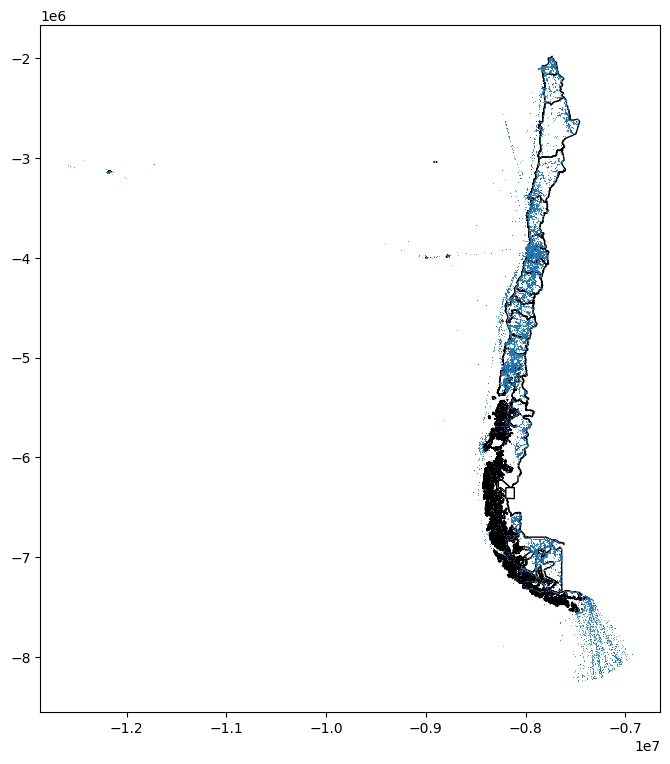

In [73]:
#Respuesta

regiones = gpd.read_file(os.path.join(path, "Regional.shp"))
regiones = regiones.set_crs(epsg=3857, allow_override=True)

gdf_aves = gdf_aves.to_crs(epsg=3857)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 12))
regiones.plot(ax=ax, color="white", edgecolor="black")
ax.scatter(gdf_aves.geometry.x, gdf_aves.geometry.y, s=0.5, alpha=0.4, linewidths=0)

ax.set_aspect("equal")
plt.show()

Se puede apreciar que hay avistamientos a los largo de todo el país, sin embargo, hay una mayor densidad en la zona central y una menor densidad en la zona norte. A su vez, podemos apreciar que también hay avistamientos en sectores maritimos y en Isla de Pascua.

### 3.4 Visualización de migraciones (2.5 puntos)

**a) (0.2 pts)** Vamos a inspeccionar los avistamientos de las siguientes 2 especies en particular:

* Run-run [(*Hymenops perspicillatus*)](https://www.avesdechile.cl/171.htm)
* Dormilona tontita [(*Muscisaxicola maclovianus*)](https://www.avesdechile.cl/043.htm)

Primero, genere dos nuevos dataframes con los avistamientos de cada especie por separado.

In [76]:
# Respuesta
#DataFrame de Run-run
df_runrun = gdf_aves[gdf_aves["comName"] == "Run-run"].reset_index(drop=True)
df_runrun.head()


,speciesCode,comName,sciName,locId,locName,obsDt,howMany,lat,lng,obsValid,obsReviewed,locationPrivate,subId,query_date,exoticCategory,month,year-month,geometry
0,spetyr1,Run-run,Hymenops perspicillatus,L17285264,"1711270, La Serena CL-Regione di Coquimbo -29....",2022-01-01 19:35:00,1.0,-29.899139,-71.270972,True,False,True,S99876937,2022-01-01,NaN,1.0,2022-01,POINT (-7933848.311 -3490591.680)
1,spetyr1,Run-run,Hymenops perspicillatus,L17285264,"1711270, La Serena CL-Regione di Coquimbo -29....",2022-01-02 20:45:00,2.0,-29.899139,-71.270972,True,False,True,S99980322,2022-01-02,NaN,1.0,2022-01,POINT (-7933848.311 -3490591.680)
2,spetyr1,Run-run,Hymenops perspicillatus,L6511037,SN Humedal Angachilla--Puente Angachilla,2022-01-03 12:36:00,11.0,-39.866534,-73.238726,True,False,False,S100101766,2022-01-03,NaN,1.0,2022-01,POINT (-8152897.651 -4846566.219)
3,spetyr1,Run-run,Hymenops perspicillatus,L9860617,Llanquihue--Humedal Baquedano,2022-01-04 21:47:00,1.0,-41.250278,-73.008892,True,False,False,S100131688,2022-01-04,NaN,1.0,2022-01,POINT (-8127312.703 -5049328.041)
4,spetyr1,Run-run,Hymenops perspicillatus,L17401377,Isla Teja--Humedal Sur,2022-01-05 20:30:00,1.0,-39.820261,-73.258060,True,False,False,S100197285,2022-01-05,NaN,1.0,2022-01,POINT (-8155049.947 -4839857.430)


In [77]:
#DataFrame de Dormilona tontita:
df_dormilona = gdf_aves[gdf_aves["comName"] == "Dormilona tontita"].reset_index(drop=True)
df_dormilona.head()


,speciesCode,comName,sciName,locId,locName,obsDt,howMany,lat,lng,obsValid,obsReviewed,locationPrivate,subId,query_date,exoticCategory,month,year-month,geometry
0,dafgrt1,Dormilona tontita,Muscisaxicola maclovianus,L17444141,Base de Las Torres,2022-01-02 04:00:00,5.0,-50.914148,-72.966255,True,False,True,S100809770,2022-01-02,NaN,1.0,2022-01,POINT (-8122566.385 -6606121.525)
1,dafgrt1,Dormilona tontita,Muscisaxicola maclovianus,L13297147,Río Alerce--Cascada Llanada Grande,2022-01-03 12:44:00,4.0,-41.871237,-71.920478,True,False,False,S100063840,2022-01-03,NaN,1.0,2022-01,POINT (-8006150.989 -5141710.843)
2,dafgrt1,Dormilona tontita,Muscisaxicola maclovianus,L1259323,PN Torres del Paine--Trek a mirador Torres del...,2022-01-04 08:13:00,2.0,-50.952222,-72.924585,True,False,False,S100992257,2022-01-04,NaN,1.0,2022-01,POINT (-8117927.713 -6612846.784)
3,dafgrt1,Dormilona tontita,Muscisaxicola maclovianus,L1030753,PN Torres del Paine--Lago Grey (sector sur),2022-01-05 08:46:00,2.0,-51.116510,-73.122983,True,False,False,S101584897,2022-01-05,NaN,1.0,2022-01,POINT (-8140013.233 -6641928.998)
4,dafgrt1,Dormilona tontita,Muscisaxicola maclovianus,L17443772,"Sendero Volcán Casablanca, Los Lagos, CL (-40....",2022-01-08 15:26:00,1.0,-40.771117,-72.171518,True,False,True,S100805036,2022-01-08,NaN,1.0,2022-01,POINT (-8034096.611 -4978639.852)


**b) (0.8 pts)** Para cada una de estas especies, agrupe los datos según `year-month`. Luego, realice un gráfico que muestre la cantidad de avistamientos en el tiempo, empezando desde enero del 2022 hasta julio de 2025. Responda: ¿cómo varía cantidad de avistamientos para estas dos especies? ¿Cuáles son sus diferencias?

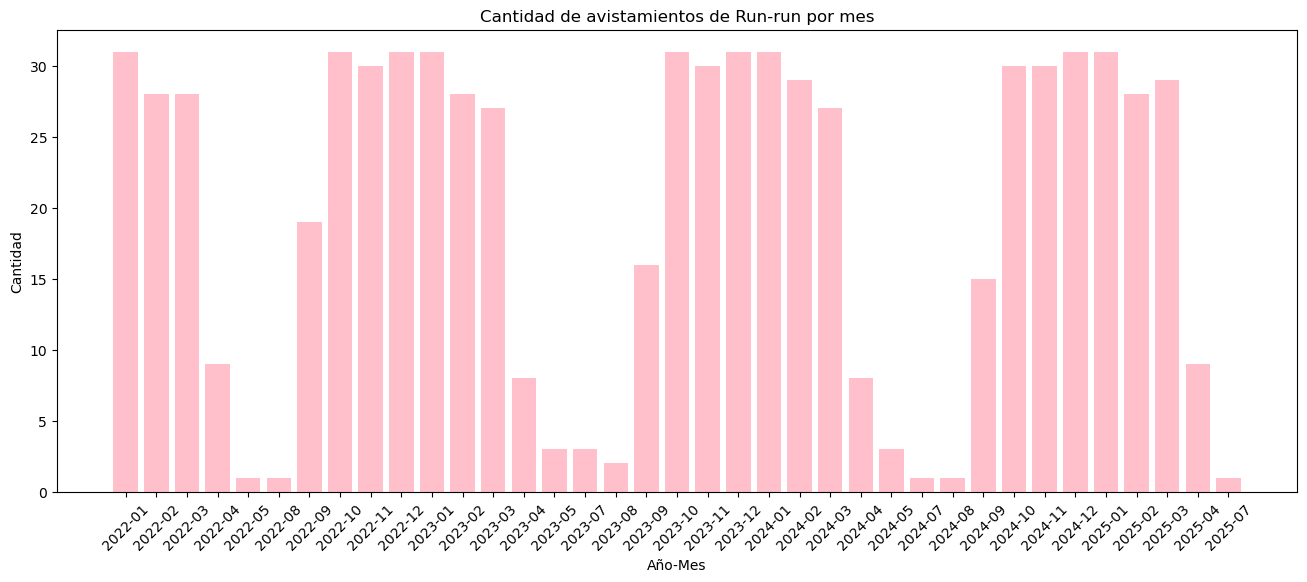

In [79]:
# Respuesta
#Avistamientos Run-run
conteo = df_runrun["year-month"].value_counts().sort_index()
plt.figure(figsize=(16, 6))
plt.bar(conteo.index, conteo.values, color = "pink")
plt.title('Cantidad de avistamientos de Run-run por mes')
plt.xlabel('Año-Mes')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.show()

Con este gráfico podemos apreciar que donde menos avistamientos hay es entre los meses de marzo y julio o, dicho de otra manera, los meses de otoño y principios de invierno. Por otro lado, los meses donde más avistamientos se registraron fueron de septiembre a febrero, en este caso siendo los meses de primevera y verano.

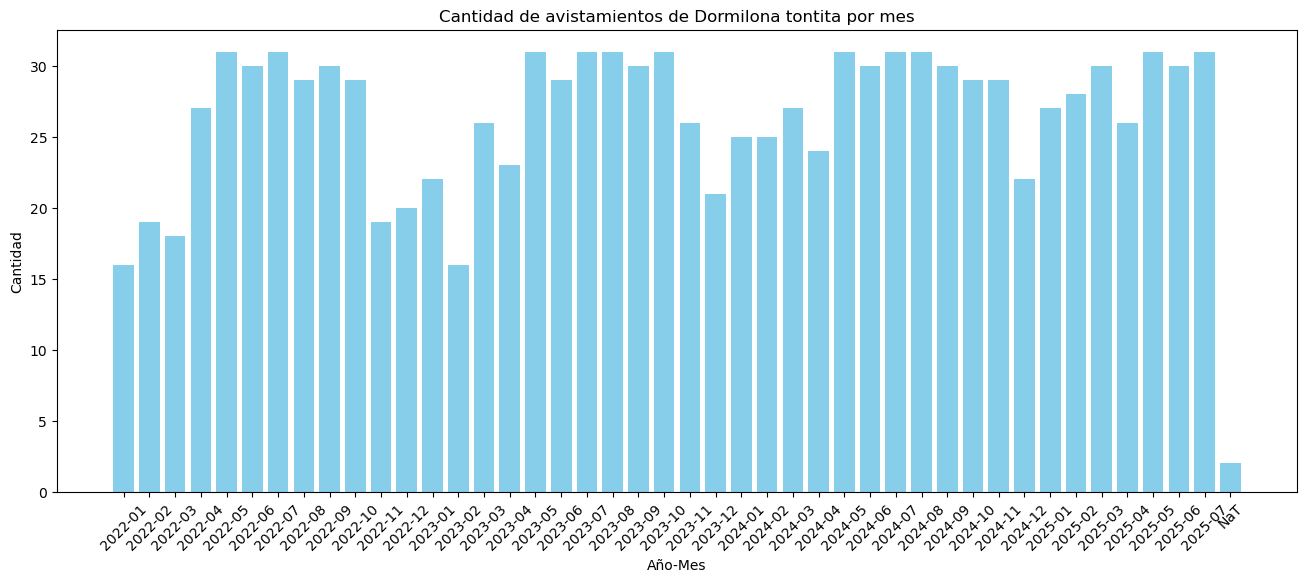

In [81]:
#Avistamientos Dormilona tontita
conteo = df_dormilona["year-month"].value_counts().sort_index()
plt.figure(figsize=(16, 6))
plt.bar(conteo.index, conteo.values, color = "skyblue")
plt.title('Cantidad de avistamientos de Dormilona tontita por mes')
plt.xlabel('Año-Mes')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.show()

En el caso de la Dormilona tontita, podemos apreciar que la diferencia entre sus meses con mayor y menor cantidad de avistamientos no es tan grande, pero sigue siendo evidente. Los meses donde menos avistamientos se registraron fueron entre octubre y marzo, o sea, principalmente en la temporada de primera y verano, mientras que en los que más avistamientos hubo fueron entre abril y septiembre, es decir, la temporada de otoño e invierno.

Al comparar los gráficos de ambas especies, podemos apreciar que los climas de su preferencia son practicamente opuestos, mientras el Run-run es visto con mayor frecuencia en primera y verano, la Dormilona tontita se encuentra más seguido en otoño e invierno. 

**b) (1 pto)** Grafique en un mapa de Chile la ubicación de cada avistamiento para cada especie mencionada por separado. Utilice el color de cada punto como indicador del mes de avistamiento (columna `month`). Para esto, utilice un **colormap cíclico** para representar los meses del año. Puede utilizar el colormap disponible en la siguiente celda, o bien utilizar otro (siempre y cuando sea cíclico).

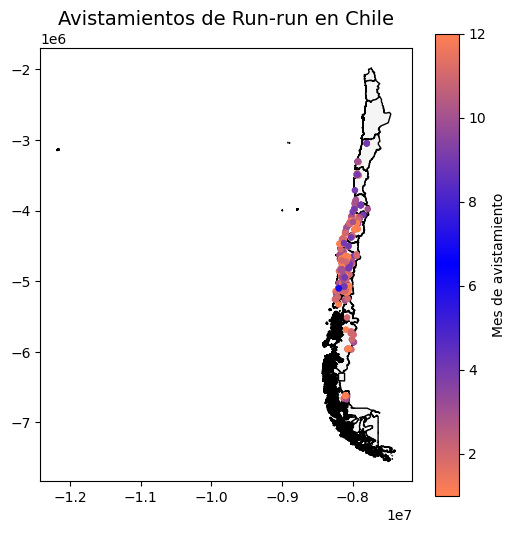

In [85]:
#Grafico de Run-run:

import matplotlib.colors as mcolors

regiones = regiones.set_crs(epsg=3857, allow_override=True)
df_runrun = df_runrun.to_crs(epsg=3857)  #Con esto me aseguro de que tengan el mismo CRS


colors = ["coral", "blue", "coral"]
positions = [0, 0.5, 1]
custom_cmap = mcolors.LinearSegmentedColormap.from_list("cyclic_cmap", list(zip(positions, colors)))

fig, ax = plt.subplots(figsize=(6, 12)) #Determino las dimensiones del mapa
regiones.plot(ax=ax, color="whitesmoke", edgecolor="black")
df_runrun.plot(
    ax=ax,
    column="month",
    cmap=custom_cmap,
    markersize=14,
    legend=True,
    legend_kwds={
        "shrink": 0.5,  
        "orientation": "vertical",
        "label": "Mes de avistamiento"})

plt.title("Avistamientos de Run-run en Chile", fontsize=14)
plt.show()

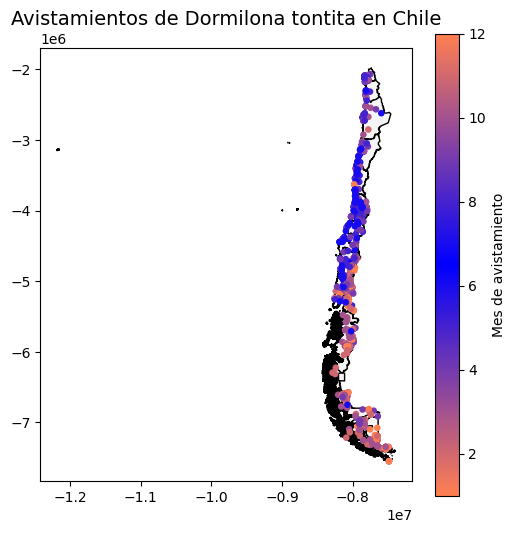

In [86]:
# Respuesta
#Gráfico de Dormilona tontita:
import matplotlib.colors as mcolors

regiones = regiones.set_crs(epsg=3857, allow_override=True)
df_dormilona = df_dormilona.to_crs(epsg=3857)  #Con esto me aseguro de que tengan el mismo CRS


colors = ["coral", "blue", "coral"]
positions = [0, 0.5, 1]
custom_cmap = mcolors.LinearSegmentedColormap.from_list("cyclic_cmap", list(zip(positions, colors)))

fig, ax = plt.subplots(figsize=(6, 12)) #Determino las dimensiones del mapa
regiones.plot(ax=ax, color="whitesmoke", edgecolor="black")
df_dormilona.plot(
    ax=ax,
    column="month",
    cmap=custom_cmap,
    markersize=14,
    legend=True,
    legend_kwds={
        "shrink": 0.5,   
        "orientation": "vertical",
        "label": "Mes de avistamiento"})

plt.title("Avistamientos de Dormilona tontita en Chile", fontsize=14)
plt.show()

**c) (0.5 pts)** Describa las migraciones de estas dos especies. ¿Cómo se diferencian?

Respuesta

Por un lado, podemos ver que las migraciones de las aves Run-run tienden a ser dentro de la zona más central del país y, como vimos anteriormente en los gráficos de barra, es evidente, por los colores de los puntos, que se aparecen más en los meses calurosos del año. Por otro lado, el ave Dormilona tontita migra por todo el país, pero podemos ver que, al hacerlo en la zona norte o centro, es principalmente en los meses más fríos del año, lo que también encaja con lo que pudimos apreciar en el gráfico previamente visto.

### Fuentes:
- https://es.stackoverflow.com/questions/580779/c%C3%B3mo-puedo-cambiar-en-pandas-el-tipo-de-variable-para-m%C3%BAltiples-columnas
- https://www.youtube.com/watch?v=EDQziwYfEkw&t=111s
- https://www.youtube.com/watch?v=EsSU0SSBPw8
- https://interactivechaos.com/es/manual/tutorial-de-pandas/ordenacion-de-dataframes-por-valor
- https://www.datacamp.com/tutorial/timedelta-python-time-intervals

### Preguntas a ChatGPT:
**Pregunta:**
Tengo dos geodataframes, uno llamado "df_runrun" y el otro "regiones". df_runrun indica la información de avistamientos de una ave en Chile, su columna "geometry" contiene los puntos donde fue visto el ave, estos los debo graficar en el mapa de Chile, para esto tenemos la ayuda de "regiones" que contiene todas las regiones de Chile y su columna "geometry" tiene datos en formato "POLYGON" y "MULTIPOLYGON". Para graficar me presentan el siguiente inicio de código: import matplotlib.colors as mcolors colors = ["coral", "blue", "coral"] positions = [0, 0.5, 1] # Creamos un colormap cíclico para representar meses del año custom_cmap = mcolors.LinearSegmentedColormap.from_list("cyclic_cmap", list(zip(positions, colors))) Estoy teniendo problemas al graficarlo, pues, a pesar de salirme los puntos, no sale la figura del mapa, solo sale un rectángulo dividido horizontalmente en 3 rectángulos. Para encontrar el problema hice las siguientes pruebas: Puse: print(regiones.crs) # Debe decir EPSG:3857 print(regiones.head()) print(regiones.geometry.is_valid.all()) # Debe ser True print(regiones.empty) # Debe ser False print(len(regiones)) # Debe tener > 0 print(regiones.total_bounds) # Debe devolver: xmin, ymin, xmax, ymax print(df_runrun.crs) # Debe coincidir con regiones (EPSG:3857) print(df_runrun.head()) print(df_runrun.geometry.is_valid.all()) # True print(df_runrun.empty) # False print(df_runrun.geometry.type.unique()) # Debe mostrar ["Point"] print(df_runrun["month"].unique()) # Deben ser números de 1 a 12 print(df_runrun["month"].isnull().sum()) # Debe ser 0 print("Regiones bounds:", regiones.total_bounds) print("Puntos bounds:", df_runrun.total_bounds) Me devolvió: EPSG:3857 nombre_region geometry 0 Región I POLYGON ((-8348961.809 -5621521.486, -7792364.... 1 Región II POLYGON ((-8348961.809 -4163881.144, -7792364.... True False 2 [-8348961.80949552 -5621521.48619207 -7792364.35552915 -3503549.84350438] EPSG:3857 speciesCode comName sciName locId \ 0 spetyr1 Run-run Hymenops perspicillatus L17285264 1 spetyr1 Run-run Hymenops perspicillatus L17285264 2 spetyr1 Run-run Hymenops perspicillatus L6511037 3 spetyr1 Run-run Hymenops perspicillatus L9860617 4 spetyr1 Run-run Hymenops perspicillatus L17401377 locName obsDt \ 0 1711270, La Serena CL-Regione di Coquimbo -29.... 2022-01-01 19:35:00 1 1711270, La Serena CL-Regione di Coquimbo -29.... 2022-01-02 20:45:00 2 SN Humedal Angachilla--Puente Angachilla 2022-01-03 12:36:00 3 Llanquihue--Humedal Baquedano 2022-01-04 21:47:00 4 Isla Teja--Humedal Sur 2022-01-05 20:30:00 howMany lat lng obsValid obsReviewed locationPrivate \ 0 1.0 -29.899139 -71.270972 True False True 1 2.0 -29.899139 -71.270972 True False True 2 11.0 -39.866534 -73.238726 True False False 3 1.0 -41.250278 -73.008892 True False False 4 1.0 -39.820261 -73.258060 True False False subId query_date exoticCategory month year-month \ 0 S99876937 2022-01-01 NaN 1.0 2022-01 1 S99980322 2022-01-02 NaN 1.0 2022-01 2 S100101766 2022-01-03 NaN 1.0 2022-01 3 S100131688 2022-01-04 NaN 1.0 2022-01 4 S100197285 2022-01-05 NaN 1.0 2022-01 geometry 0 POINT (-7933848.311 -3490591.680) 1 POINT (-7933848.311 -3490591.680) 2 POINT (-8152897.651 -4846566.219) 3 POINT (-8127312.703 -5049328.041) 4 POINT (-8155049.947 -4839857.430) True False ['Point'] [ 1. 2. 3. 4. 5. 8. 9. 10. 11. 12. 7.] 0 Regiones bounds: [-8348961.80949552 -5621521.48619207 -7792364.35552915 -3503549.84350438] Puntos bounds: [-8249450.29991721 -6674124.62943816 -7784002.99272838 -3047929.28705716] Puse: fig, ax = plt.subplots(figsize=(12, 10)) regiones.plot(ax=ax, color="whitesmoke", edgecolor="black") plt.show() Y no se ve el mapa de Chile, se ve la imagen que adjunté. Puse: fig, ax = plt.subplots(figsize=(12, 10)) df_runrun.plot(ax=ax, color="red", markersize=20) plt.show() Y sí se ven los puntos. Puse: fig, ax = plt.subplots(figsize=(12, 10)) regiones.plot(ax=ax, color="whitesmoke", edgecolor="black") df_runrun.plot(ax=ax, color="red", markersize=20) plt.show() Y se ve como la segunda imagen que adjunté. Puse: xmin, ymin, xmax, ymax = regiones.total_bounds ax.set_xlim(xmin, xmax) ax.set_ylim(ymin, ymax) Y me devolvió: (-5621521.486192066, -3503549.8435043753)

**Respuesta:**
Gracias por los pantallazos 🙌.
👉 El problema no está en df_runrun, sino en regiones:
Tu GeoDataFrame de regiones solo tiene 2 polígonos rectangulares enormes (lo que se ve en gris claro en tus gráficos). Por eso, al graficar, aparecen dos cajas en vez del contorno real de Chile.
Lo confirmamos con esto que imprimiste:
len(regiones) → 2
Eso significa que tu shapefile (o lo que hayas cargado en regiones) tiene dos features nada más, ambas rectángulos que parecen ser "bounding boxes" de regiones, no las geometrías detalladas.
________________________________________
Cómo avanzar
1.	Revisar el origen de regiones
o	Si lo leíste de un shapefile, probablemente cargaste un archivo equivocado (ej: límites en cuadrículas y no las divisiones regionales).
o	Si lo sacaste de alguna API o dataset, puede que venga simplificado o mal exportado.
2.	Comprobar los nombres y geometrías
Haz:
print(regiones["nombre_region"].unique())
print(regiones.geometry.head().to_string())
Seguro ves que son solo “Región I”, “Región II” con geometrías tipo POLYGON ((xmin ymin, xmax ymin, xmax ymax, xmin ymax, xmin ymin)), es decir, cajas.
3.	Conseguir el shapefile correcto
Para Chile puedes usar:
o	El portal de datos del INE o Biblioteca del Congreso Nacional (shapefiles oficiales de regiones).
o	También está disponible vía geoBoundaries o GADM:
is (si tienes internet)
url = "https://www.geoboundaries.org/data/geoBoundaries-3_0_0/CHL/ADM1/geoBoundaries-CHL-ADM1.geojson"
regiones = gpd.read_file(url)
print(regiones.head())
Eso te da todas las regiones de Chile con sus polígonos.
4.	Volver a graficar
Cuando tengas el shapefile correcto:
fig, ax = plt.subplots(figsize=(8, 10))
regiones.plot(ax=ax, color="whitesmoke", edgecolor="black")
df_runrun.plot(ax=ax, column="month"

, cmap=custom_cmap, markersi
**Antes si me había funcionado el GeoDataFrame de las regiones, por lo que corrí todaslas celdas desde el principi

o y le mostré lo siguiente:**
Corrí el código desde el principio y ahora me sale esto: Puse: print(regiones.crs) # Debe decir EPSG:3857 print(regiones.head()) print(regiones.geometry.is_valid.all()) # Debe ser True print(regiones.empty) # Debe ser False print(len(regiones)) # Debe tener > 0 print(regiones.total_bounds) # Debe devolver: xmin, ymin, xmax, ymax print(df_runrun.crs) # Debe coincidir con regiones (EPSG:3857) print(df_runrun.head()) print(df_runrun.geometry.is_valid.all()) # True print(df_runrun.empty) # False print(df_runrun.geometry.type.unique()) # Debe mostrar ["Point"] print(df_runrun["month"].unique()) # Deben ser números de 1 a 12 print(df_runrun["month"].isnull().sum()) # Debe ser 0 print("Regiones bounds:", regiones.total_bounds) print("Puntos bounds:", df_runrun.total_bounds) Y me devolvió esto: +init=epsg:4326 +type=crs objectid cir_sena codregion area_km st_area_sh st_length_ \ 0 1084 1 15 16866.819844 1.886869e+10 7.505296e+05 1 1085 2 1 42284.567484 4.830637e+10 1.213713e+06 2 1086 3 2 126071.431981 1.508452e+11 2.516112e+06 3 1087 15 12 133053.142345 3.581316e+11 9.049830e+07 4 1088 14 11 106703.377369 2.242743e+11 4.144481e+07 Region \ 0 Región de Arica y Parinacota 1 Región de Tarapacá 2 Región de Antofagasta 3 Región de Magallanes y Antártica Chilena 4 Región de Aysén del Gral.Ibañez del Campo geometry 0 POLYGON ((-7727277.27780 -1997230.76830, -7726... 1 MULTIPOLYGON (((-7810213.51540 -2298008.28020,... 2 MULTIPOLYGON (((-7870470.96080 -2985679.18570,... 3 MULTIPOLYGON (((-7494057.53490 -7542535.38330,... 4 MULTIPOLYGON (((-8413517.69600 -6234055.25490,... False False 17 [-12184465.5292 -7554435.5874 -7393641.8015 -1978919.7457] +init=epsg:4326 +type=crs speciesCode comName sciName locId \ 0 spetyr1 Run-run Hymenops perspicillatus L17285264 1 spetyr1 Run-run Hymenops perspicillatus L17285264 2 spetyr1 Run-run Hymenops perspicillatus L6511037 3 spetyr1 Run-run Hymenops perspicillatus L9860617 4 spetyr1 Run-run Hymenops perspicillatus L17401377 locName obsDt \ 0 1711270, La Serena CL-Regione di Coquimbo -29.... 2022-01-01 19:35:00 1 1711270, La Serena CL-Regione di Coquimbo -29.... 2022-01-02 20:45:00 2 SN Humedal Angachilla--Puente Angachilla 2022-01-03 12:36:00 3 Llanquihue--Humedal Baquedano 2022-01-04 21:47:00 4 Isla Teja--Humedal Sur 2022-01-05 20:30:00 howMany lat lng obsValid obsReviewed locationPrivate \ 0 1.0 -29.899139 -71.270972 True False True 1 2.0 -29.899139 -71.270972 True False True 2 11.0 -39.866534 -73.238726 True False False 3 1.0 -41.250278 -73.008892 True False False 4 1.0 -39.820261 -73.258060 True False False subId query_date exoticCategory month year-month \ 0 S99876937 2022-01-01 NaN 1.0 2022-01 1 S99980322 2022-01-02 NaN 1.0 2022-01 2 S100101766 2022-01-03 NaN 1.0 2022-01 3 S100131688 2022-01-04 NaN 1.0 2022-01 4 S100197285 2022-01-05 NaN 1.0 2022-01 geometry 0 POINT (-71.27097 -29.89914) 1 POINT (-71.27097 -29.89914) 2 POINT (-73.23873 -39.86653) 3 POINT (-73.00889 -41.25028) 4 POINT (-73.25806 -39.82026) True False ['Point'] [ 1. 2. 3. 4. 5. 8. 9. 10. 11. 12. 7.] 0 Regiones bounds: [-12184465.5292 -7554435.5874 -7393641.8015 -1978919.7457] Puntos bounds: [-74.1060729 -51.2977074 -69.9248886 -26.3937373] Puse esto: fig, ax = plt.subplots(figsize=(12, 10)) regiones.plot(ax=ax, color="whitesmoke", edgecolor="black") plt.show() Y se ve el mapa, pero quedó muy delgado, como aplastado. Puse esto: fig, ax = plt.subplots(figsize=(12, 10)) df_runrun.plot(ax=ax, color="red", markersize=20) plt.show() Y se ven los puntos. Puse esto: fig, ax = plt.subplots(figsize=(12, 10)) regiones.plot(ax=ax, color="whitesmoke", edgecolor="black") df_runrun.plot(ax=ax, color="red", markersize=20) plt.show() Y se ve lo que puse de foto, hay un punto rojo en la esquina superior derecha. Puse esto: print(regiones["Region"].unique()) print(regiones.geometry.head().to_string()) Y me devolvió esto: ['Región de Arica y Parinacota' 'Región de Tarapacá' 'Región de Antofagasta' 'Región de Magallanes y Antártica Chilena' 'Región de Aysén del Gral.Ibañez del Campo' 'Región de Atacama' 'Región de Coquimbo' 'Región de Valparaíso' 'Región Metropolitana de Santiago' 'Región de Los Lagos' 'Región de Los Ríos' 'Región de La Araucanía' 'Región del Bío-Bío' 'Región de Ñuble' 'Región del Maule' "Región del Libertador Bernardo O'Higgins" 'Zona sin demarcar'] 0 POLYGON ((-7727277.27780 -1997230.76830, -7726... 1 MULTIPOLYGON (((-7810213.51540 -2298008.28020,... 2 MULTIPOLYGON (((-7870470.96080 -2985679.18570,... 3 MULTIPOLYGON (((-7494057.53490 -7542535.38330,... 4 MULTIPOLYGON (((-8413517.69600 -6234055.25490,...

**Respuesta:**
import geopandas as gpd
import matplotlib.pyplot asRevisar CRS y bounds originales ---
print("CRS regiones antes:", regiones.crs)
print("Bounds regiones antes:", regiones.total_bounds)

print("CRS df_runrun antes:", df_runral_bounds)

# --- 2. Corregir CRS ---
regiones = regiones.set_cr3857)

# --- 3. Verificar nuevamente ---
print("CRS regiones después:", regiones.crs)
print("Bounds regiones después:", regiones.total_bounds)

print("
# --- 4. Definir colormap cíclico para meses ---
colors = ["coral", "blue", "coral"]
positions = [0, 0.5, 1]
custom_cmap = mcolors.LinearSegmentedColormap.f_cmap", list(zip(positions, colors))
)", edgecolor="black")

# Avistamientos coloreados por mes
df_runrun.plot(
    ax=ax,
    column="month",
    cmap=custom_cmap,
    markersize=15,
    legend=True
)

plt.title("Avistamientos de Run-run en Chile", fontsize=14)
plt.show()
ze=20, legend=True)
plt.show()
